In [1]:
#import data manipulation libraries
import numpy as np
import pandas as pd

#import data visualziation libraries
import matplotlib.pyplot as plt
import seaborn as sns

#import logging 
import logging
logging.basicConfig(filename='model.log',
                    level=logging.INFO,
                    filemode='w',
                      format='%(asctime)s:%(levelname)s:%(message)s',
                      force=True)

import warnings
warnings.filterwarnings('ignore')

In [3]:
#data import using pandas function
df=pd.read_excel('Real estate valuation data set.xlsx')
#shuffle the dataset
df.sample(frac=1)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
346,347,2013.416667,13.2,1712.6320,2,24.96412,121.51670,30.8
293,294,2012.666667,12.6,383.2805,7,24.96735,121.54464,42.5
67,68,2013.500000,8.5,104.8101,5,24.96674,121.54067,56.8
221,222,2013.333333,9.0,1402.0160,0,24.98569,121.52760,38.5
257,258,2013.250000,17.3,444.1334,1,24.97501,121.52730,43.9
...,...,...,...,...,...,...,...,...
325,326,2013.083333,36.6,488.8193,8,24.97015,121.54494,38.1
232,233,2012.916667,27.1,4412.7650,1,24.95032,121.49587,17.4
92,93,2012.916667,20.6,2469.6450,4,24.96108,121.51046,21.8
34,35,2012.750000,15.4,205.3670,7,24.98419,121.54243,55.1


In [4]:
#separating numerical and categorical data
numerical_data=df.select_dtypes(exclude=object)
categorial_data=df.select_dtypes(include=object)

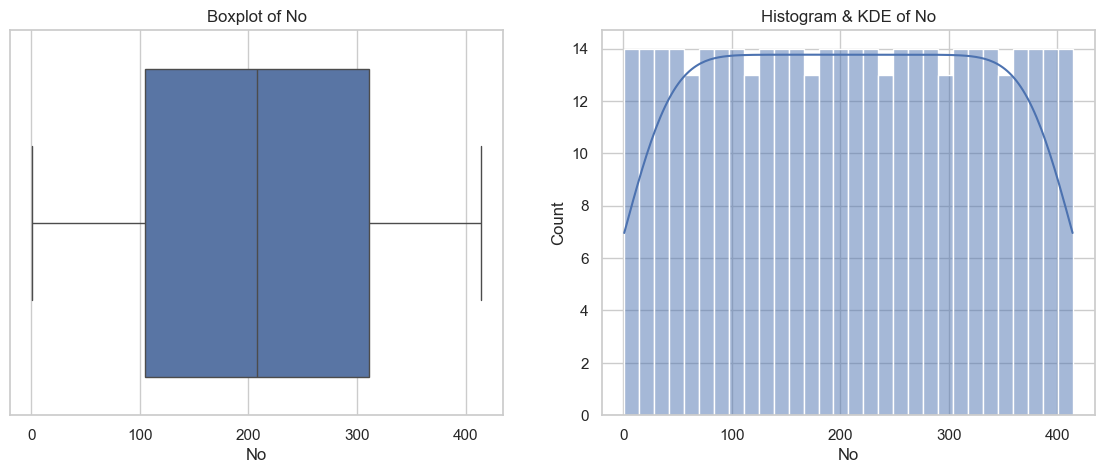

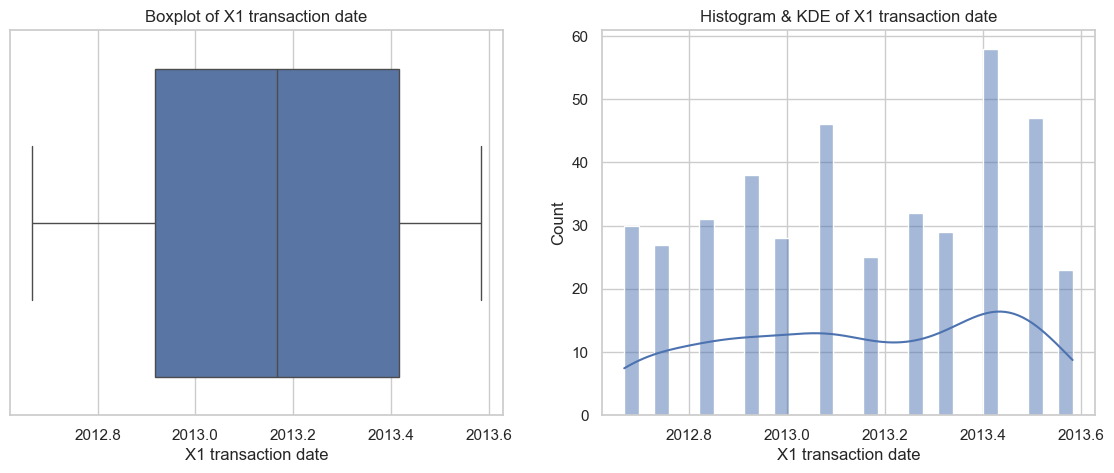

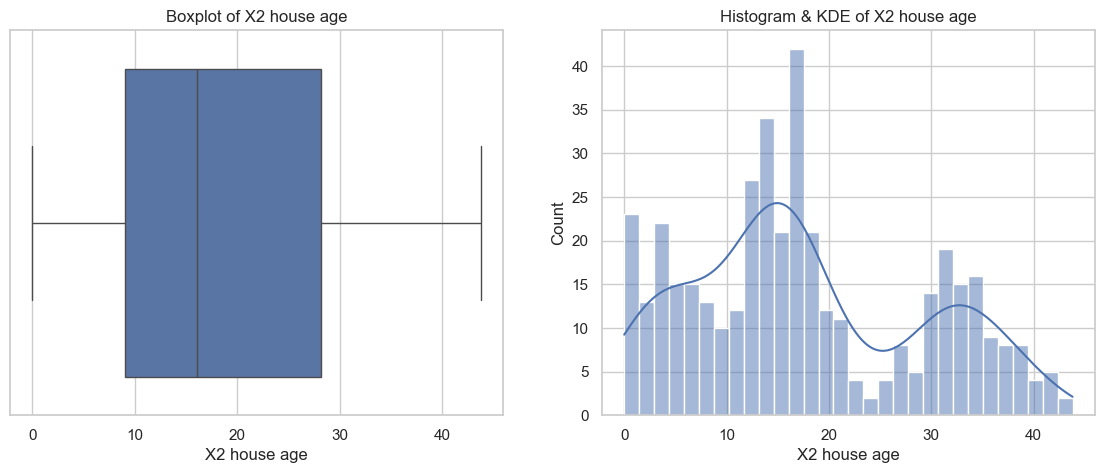

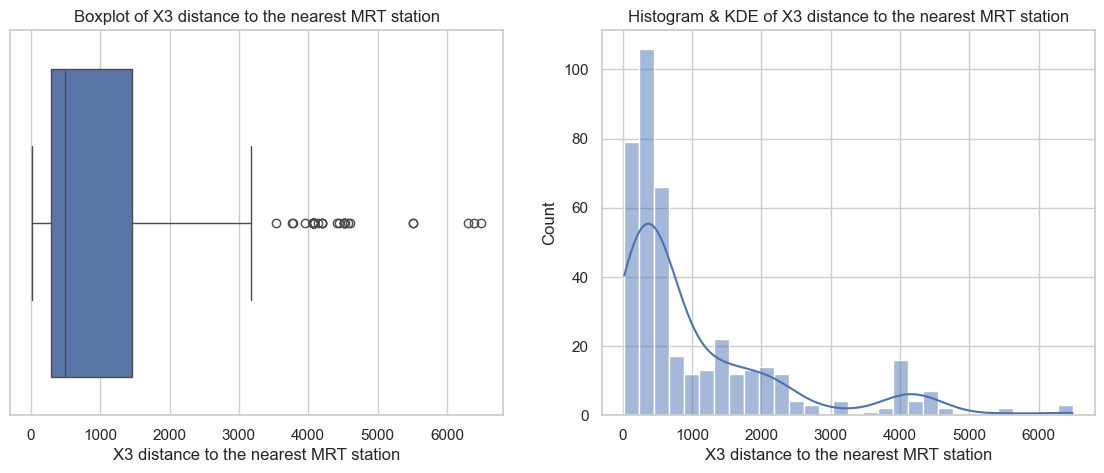

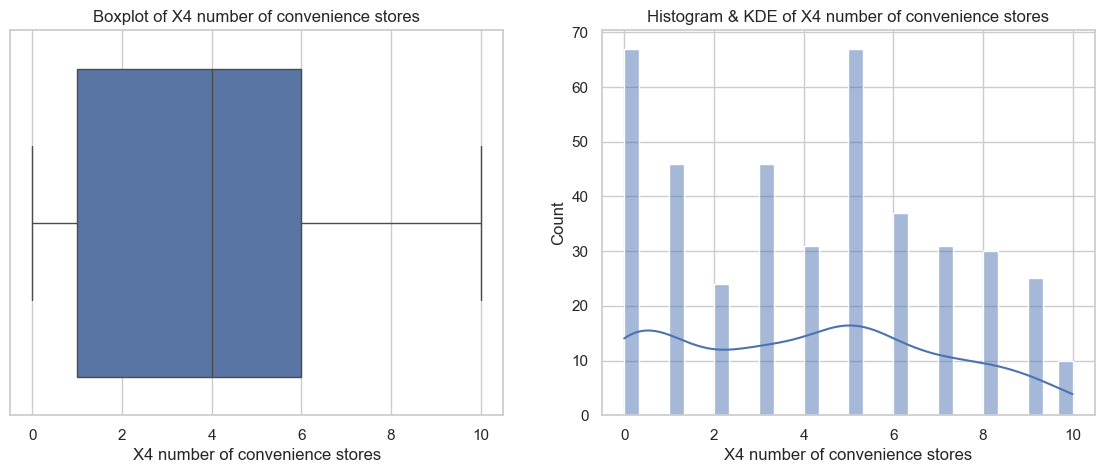

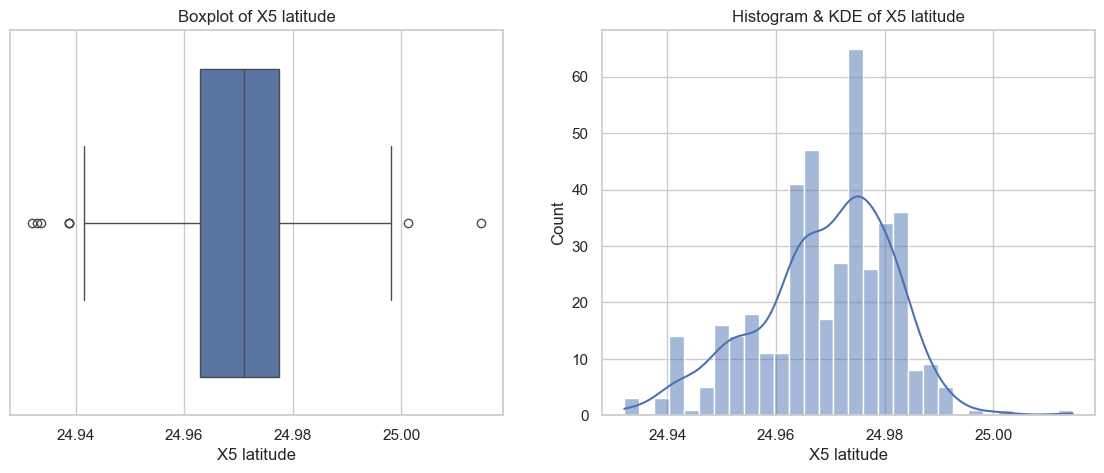

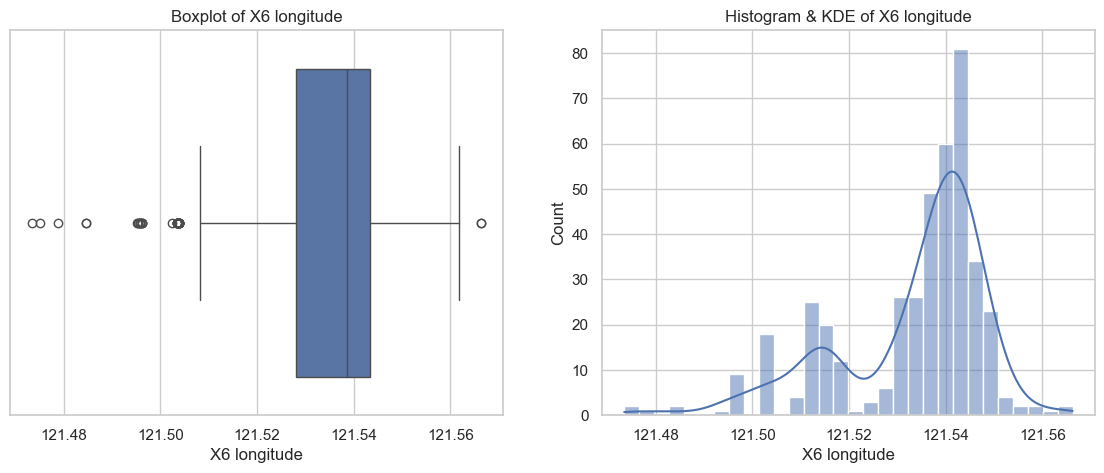

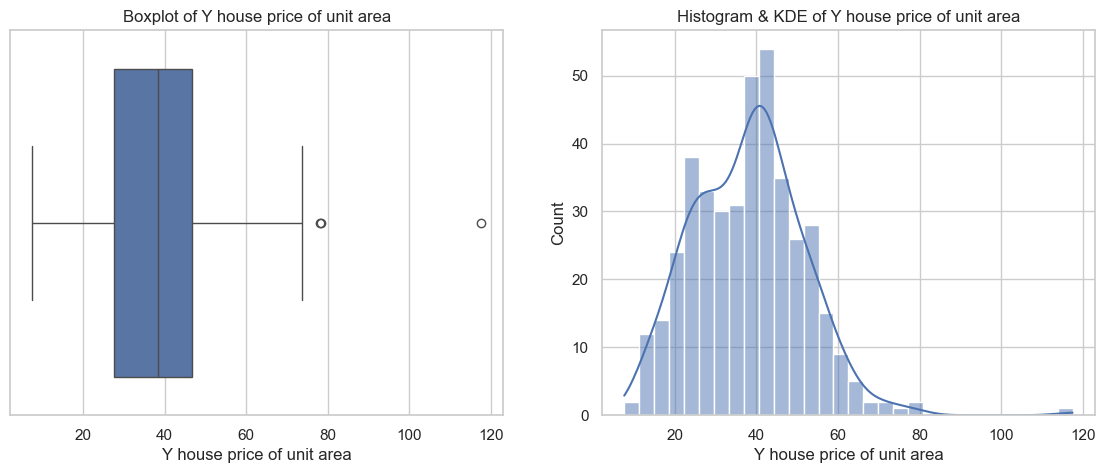

In [5]:
#checking for outliers

sns.set(style="whitegrid")

# Plot boxplots and bell curves for each numerical feature
for col in numerical_data.columns:
    plt.figure(figsize=(14, 5))
    
    # Boxplot (shows outliers as points beyond whiskers)
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    
    # Bell curve: histogram + KDE (to check distribution shape)
    plt.subplot(1, 2, 2)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram & KDE of {col}')
    
    plt.show()

In [6]:
#performing EDA

from collections import OrderedDict
stats=[]
for i in numerical_data:
    numerical_stats=OrderedDict({
        'feature':i,
        'mean':df[i].mean(),
        'median':df[i].median(),
        'mode':df[i].mode()[0],
        'std':df[i].std(),
        'min':df[i].min(),
        'max':df[i].max(),
        'skewness':df[i].skew(),
        'kurtosis':df[i].kurt()
    })
    stats.append(numerical_stats)
    report=pd.DataFrame(stats)


# Outlier Identification :
outlier_label = []
for col in report['feature']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    LW = Q1 - 1.5 * IQR   # LW : Lower Whisker Line
    UW = Q3 + 1.5 * IQR   # UW : Upper Whisker Line
    outliers = df[(df[col] < LW) | (df[col] > UW)]
    if not outliers.empty:
        outlier_label.append("Has Outliers")
    else:
        outlier_label.append("No Outliers")

report["Outlier Comment"] = outlier_label

# Checking Report
report

,feature,mean,median,mode,std,min,max,skewness,kurtosis,Outlier Comment
0,No,207.500000,207.500000,1.000000,119.655756,1.000000,414.000000,0.000000,-1.200000,No Outliers
1,X1 transaction date,2013.148953,2013.166667,2013.416667,0.281995,2012.666667,2013.583333,-0.150834,-1.231946,No Outliers
2,X2 house age,17.712560,16.100000,0.000000,11.392485,0.000000,43.800000,0.382926,-0.877120,No Outliers
3,X3 distance to the nearest MRT station,1083.885689,492.231300,289.324800,1262.109595,23.382840,6488.021000,1.888757,3.207868,Has Outliers
4,X4 number of convenience stores,4.094203,4.000000,0.000000,2.945562,0.000000,10.000000,0.154607,-1.065751,No Outliers
5,X5 latitude,24.969030,24.971100,24.974330,0.012410,24.932070,25.014590,-0.438598,0.269070,Has Outliers
6,X6 longitude,121.533361,121.538630,121.543480,0.015347,121.473530,121.566270,-1.219591,1.201792,Has Outliers
7,Y house price of unit area,37.980193,38.450000,24.700000,13.606488,7.600000,117.500000,0.599853,2.179097,Has Outliers


In [11]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [13]:
#using labelencoder to encode all the categorical data
#using labelencoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    combined[col] = le.fit_transform(combined[col])

In [14]:
#train test split
X=df.drop('Y house price of unit area',axis=1)
y=df['Y house price of unit area']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)


In [19]:
#the dataset has minor outliers
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train



array([[0.15012107, 0.27272729, 0.39269406, ..., 0.3       , 0.31925007,
        0.42063834],
       [0.33656174, 0.        , 0.29452055, ..., 0.5       , 0.34724056,
        0.68837611],
       [0.39951574, 0.27272729, 0.31278539, ..., 0.1       , 0.50290467,
        0.86672418],
       ...,
       [0.06053269, 0.45454541, 0.66894977, ..., 0.2       , 0.48283602,
        0.47153332],
       [0.47457627, 0.36363635, 0.52054795, ..., 0.2       , 0.55650911,
        0.79361656],
       [0.42372881, 0.45454541, 0.68949772, ..., 0.3       , 0.41193557,
        0.6906405 ]])

In [20]:
#using linear regression

from sklearn.linear_model import LinearRegression

LR=LinearRegression()

LR.fit(X_train,y_train)

y_pred_LR=LR.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

r2_score_LR=r2_score(y_test,y_pred_LR)
r2_score_LR

0.5624551306464161

In [21]:
#using random forest
from sklearn.ensemble import RandomForestRegressor

RF=RandomForestRegressor()

RF.fit(X_train,y_train)

y_pred_RF=RF.predict(X_test)

r2_score_RF = r2_score(y_test,y_pred_RF)
print(f'The R2 Score for ',r2_score_RF)

The R2 Score for  0.6387614331453496


In [22]:
#using decision tree
from sklearn.tree import DecisionTreeRegressor

DT=DecisionTreeRegressor()

DT.fit(X_train,y_train)

y_pred_DT=DT.predict(X_test)

r2_score_DT=r2_score(y_test,y_pred_DT)
r2_score_DT

0.12994455199214971

In [23]:
#using XGBoost
import xgboost as xgb

XGB = xgb.XGBRegressor()

XGB.fit(X_train, y_train)

y_pred_XGB = XGB.predict(X_test)

r2_score_XGB = r2_score(y_test, y_pred_XGB)

r2_score_XGB

0.5544589436746372

In [24]:
#using adaboost
from sklearn.ensemble import AdaBoostRegressor
ADA=AdaBoostRegressor()

ADA.fit(X_train, y_train)

y_pred_ADA = ADA.predict(X_test)

r2_score_ADA = r2_score(y_test, y_pred_ADA)

print(f'The R2 Score for AdaBoost Model: {r2_score_ADA}')

The R2 Score for AdaBoost Model: 0.5952214536846084


In [25]:
#using grid search
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define model and parameter grid
model=RandomForestRegressor(random_state=42)
param_grid = {'n_estimators': [25,50,100, 200, 300, 400,500],'max_depth': [None, 10,20,30,40,50]}

#Grid Search Cv
grid_search = GridSearchCV(model, param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best Model
best_model = grid_search.best_estimator_
y_pred=best_model.predict(X_test)

#print result
print('Best Parameters:', grid_search.best_params_)
print('R2 Score:', r2_score(y_test, y_pred))

Best Parameters: {'max_depth': None, 'n_estimators': 25}
R2 Score: 0.6325312651733073


In [26]:
#random forest gave the best score